In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df.shape

(8807, 12)

In [5]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
df.isnull().sum().sum()

np.int64(4307)

In [8]:
print(round(df["director"].isnull().mean(),3))
print(round(df["cast"].isnull().mean(),3))
print(round(df["country"].isnull().mean(),3))
# 29.9% nulls in director column
#9% null in cast,9% in country

0.299
0.094
0.094


In [9]:
data=df.copy()

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
print("percentage of nulls in director column stored in data",data["director"].isnull().sum()/len(data)*100)

percentage of nulls in director column stored in data 29.908027705234474


In [12]:
#filling missing values with unknown
data["director"]=data["director"].fillna("Unknown")
data["cast"]=data["cast"].fillna("Unknown")
data["country"]=data["country"].fillna("Unknown")
data["date_added"]=data["date_added"].fillna("Unknown")

In [13]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [14]:
df["date_added"]

0       September 25, 2021
1       September 24, 2021
2       September 24, 2021
3       September 24, 2021
4       September 24, 2021
               ...        
8802     November 20, 2019
8803          July 1, 2019
8804      November 1, 2019
8805      January 11, 2020
8806         March 2, 2019
Name: date_added, Length: 8807, dtype: str

In [15]:
data["date_added"]=pd.to_datetime(data["date_added"],errors="coerce") 
# coerce - it conevrts invalid values into missing value(NaT/NaN) instead of giving an error
# date can be of mixed format ,so we can use format="mixed"


In [16]:
data["date_added"].dtype

dtype('<M8[us]')

In [17]:
data["year_added"] = data["date_added"].dt.year

In [18]:
data["month_added"] = data["date_added"].dt.month

In [19]:
data[["date_added", "year_added", "month_added"]].head()

,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [20]:
data["director"].value_counts()["Unknown"]

np.int64(2634)

In [21]:
print("Number of nulls in the entire dataset:",(data == "Unknown").sum().sum())

Number of nulls in the entire dataset: 4291


In [22]:
print(f"percentage of nulls in the dataset:{  round((4291*100)/(8807*12),2)  }%" )

percentage of nulls in the dataset:4.06%


In [23]:
len(data)

8807

In [24]:
print(data["director"].isnull().sum()/len(data)*100)

0.0


# EDA

In [25]:
data["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

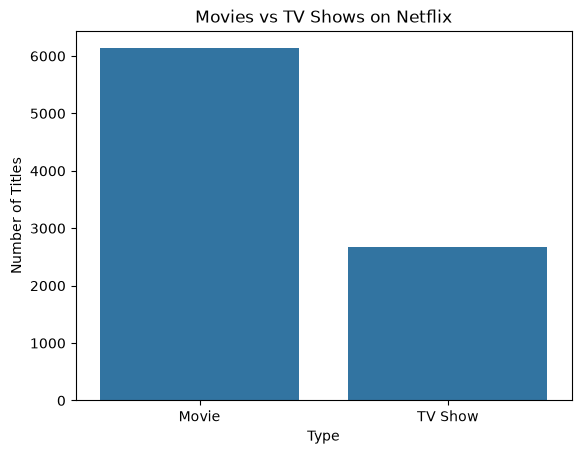

In [26]:
sns.countplot(data=data, x="type")

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Type")
plt.ylabel("Number of Titles")
plt.show()

In [27]:
data["type"].value_counts(normalize=True)*100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

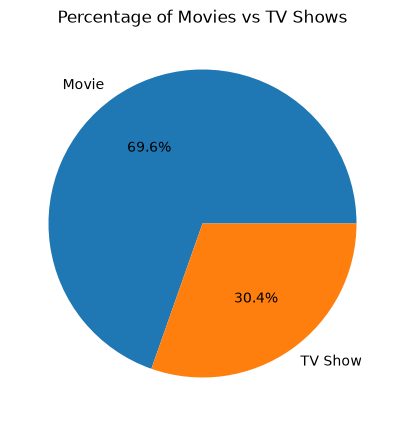

In [28]:
plt.figure(figsize=(5,5))
data["type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Percentage of Movies vs TV Shows")
plt.ylabel("")
plt.show()

In [29]:
year_count = data["release_year"].value_counts().sort_index()
year_count.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

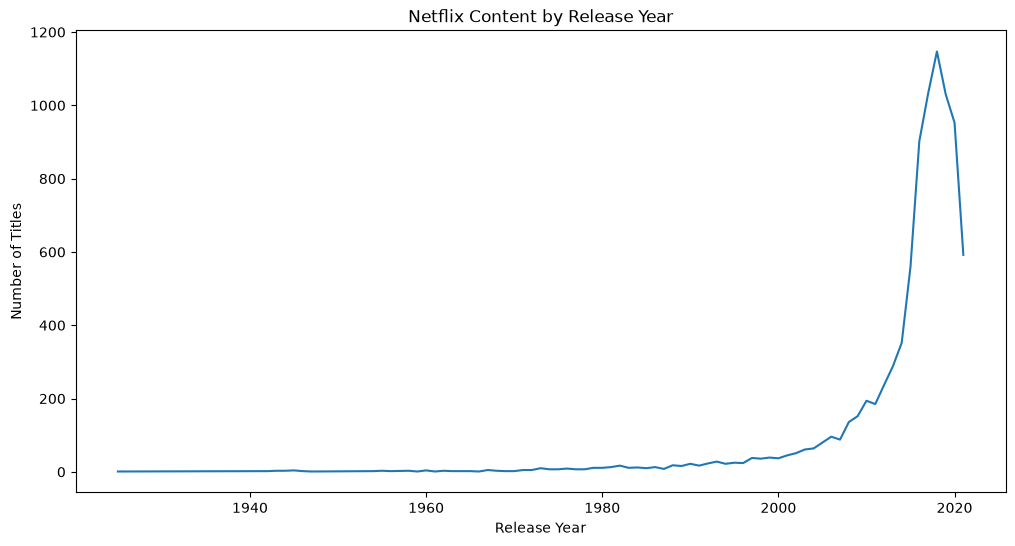

In [30]:
plt.figure(figsize=(12, 6))

plt.plot(year_count.index, year_count.values)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [31]:
added_year = data["year_added"].value_counts().sort_index()

added_year

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

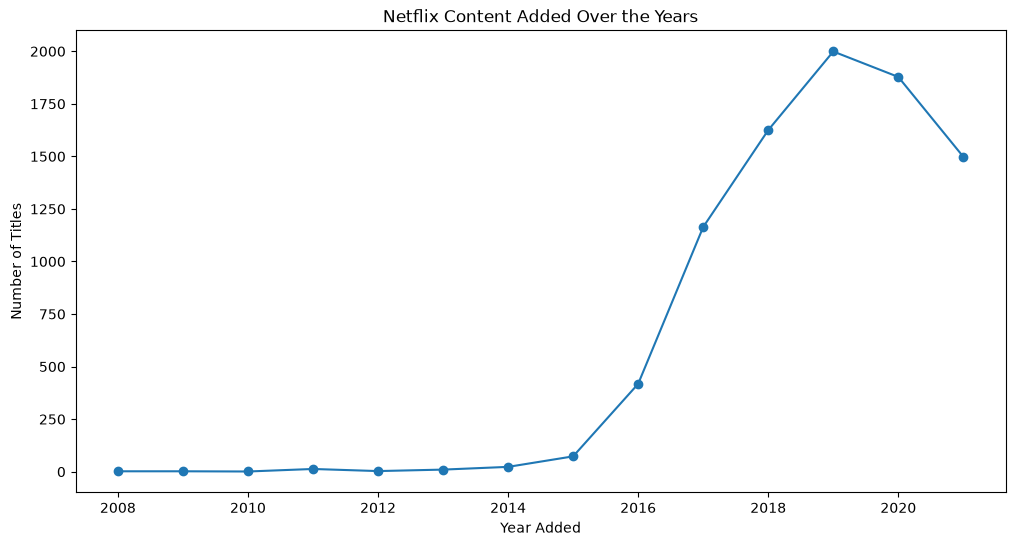

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(added_year.index, added_year.values, marker="o")

plt.title("Netflix Content Added Over the Years")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")

plt.show()

In [33]:
# top 10 country 
country_count = (
    data["country"]
    .str.split(", ")
    .explode()
    .value_counts()
)
country_count.head(10)
# split() if multiple value in a row separated by comma then it convert them into a list
# explode() takes each values(string here) from the list ,separate row for each list value

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

In [34]:
year_type = (
    data.groupby(["release_year", "type"])
    .size()
    .reset_index(name="count")
)
year_type.head()

,release_year,type,count
0,1925,TV Show,1
1,1942,Movie,2
2,1943,Movie,3
3,1944,Movie,3
4,1945,Movie,3


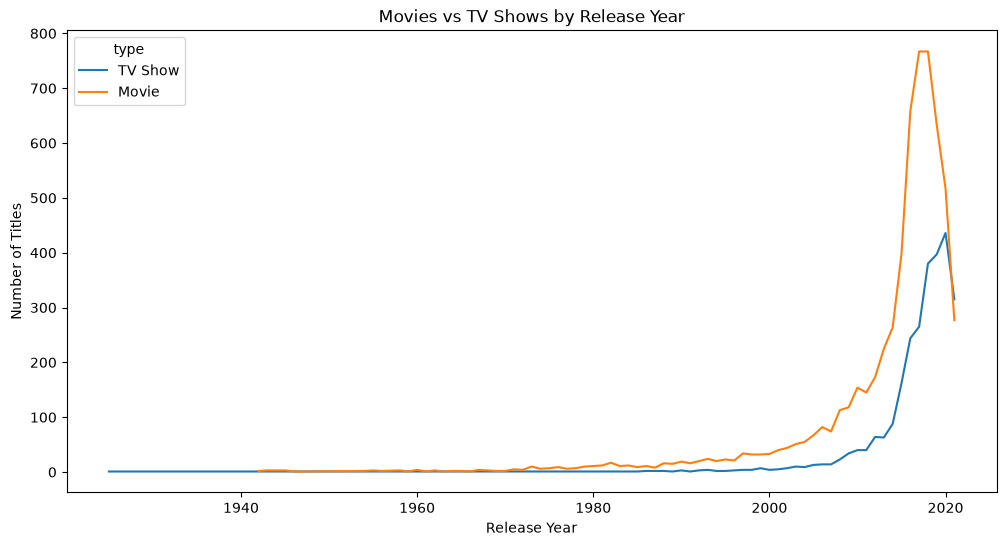

In [35]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=year_type,
    x="release_year",
    y="count",
    hue="type"
)

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

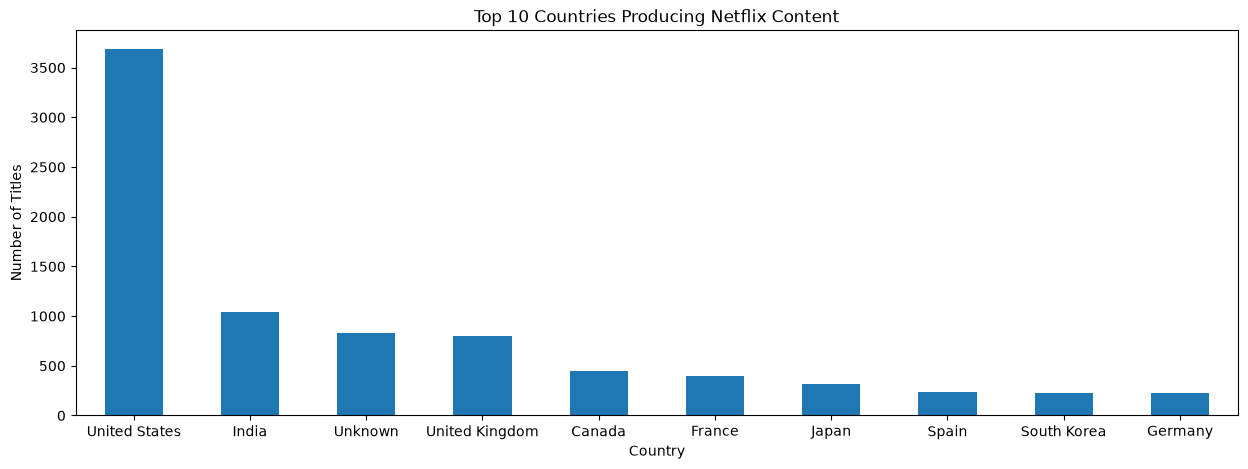

In [36]:
plt.figure(figsize=(15, 5))

country_count.head(10).plot(kind="bar")

plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=0)

plt.show()

In [37]:
genre_count = (
    data["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
)

genre_count.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

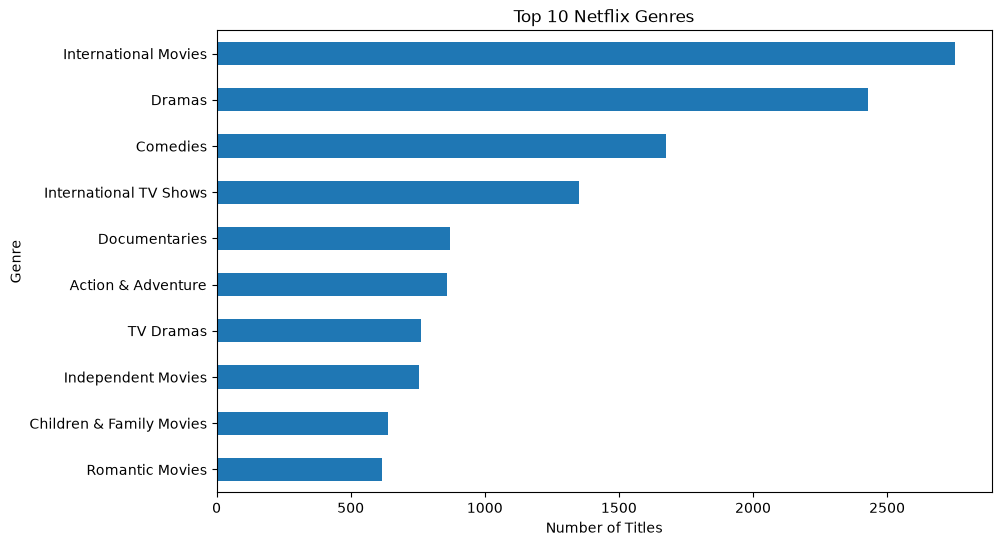

In [38]:
plt.figure(figsize=(10, 6))

genre_count.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.show()

In [39]:
rating_count = data["rating"].value_counts()

rating_count.head(10)

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

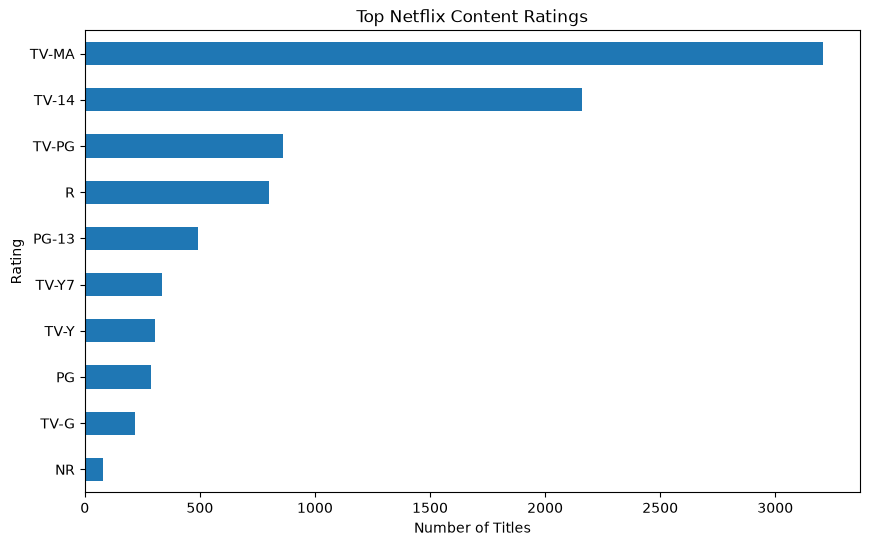

In [40]:
plt.figure(figsize=(10, 6))

rating_count.head(10).sort_values().plot(kind="barh")

plt.title("Top Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

In [41]:
director_count = (
    data[data["director"] != "Unknown"]["director"]
    .value_counts()
)

director_count.head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

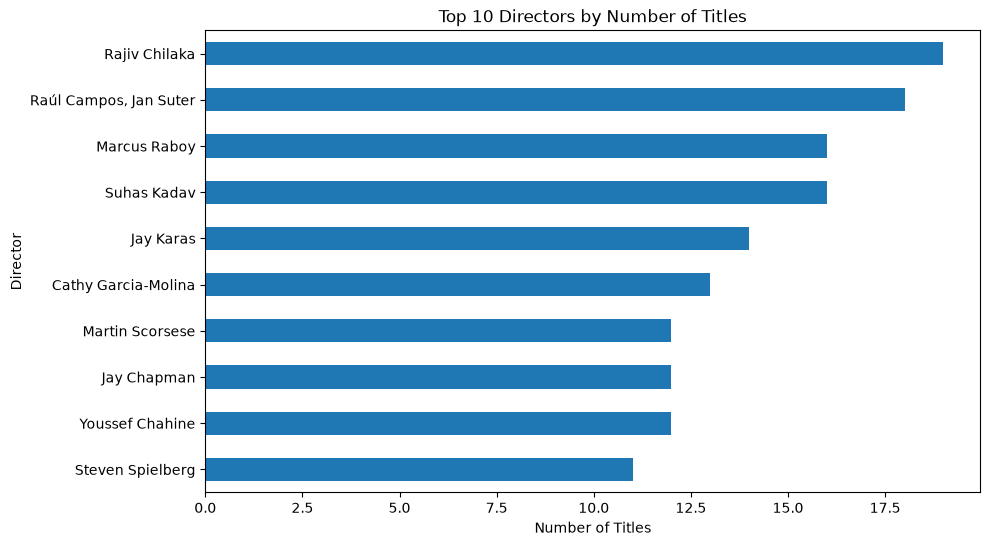

In [42]:
plt.figure(figsize=(10, 6))

director_count.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")

plt.show()

In [43]:
data["duration_minutes"] = data[data["type"] == "Movie"]["duration"].str.replace(" min", "", regex=False).astype(float)

In [44]:
movie_duration = data[ data["type"] == "Movie"]["duration_minutes"]
movie_duration.describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

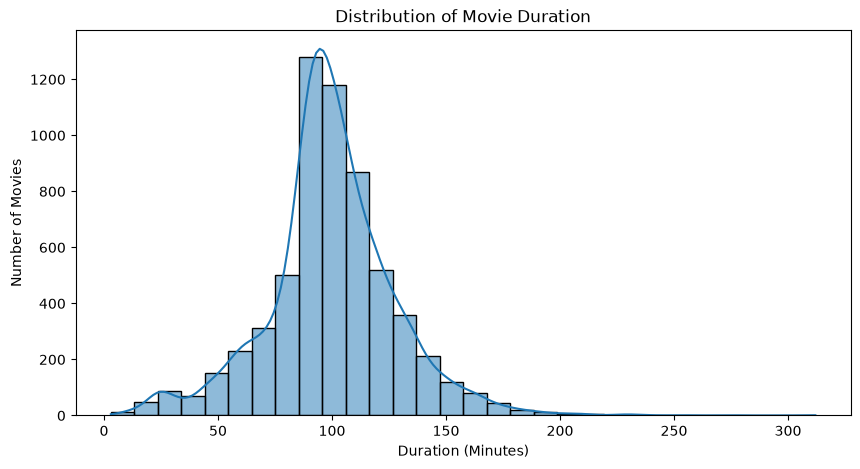

In [45]:
plt.figure(figsize=(10, 5))

sns.histplot(
    movie_duration,
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [46]:
data["month_added"] = data["date_added"].dt.month

month_count = data["month_added"].value_counts().sort_index()

month_count

month_added
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
Name: count, dtype: int64

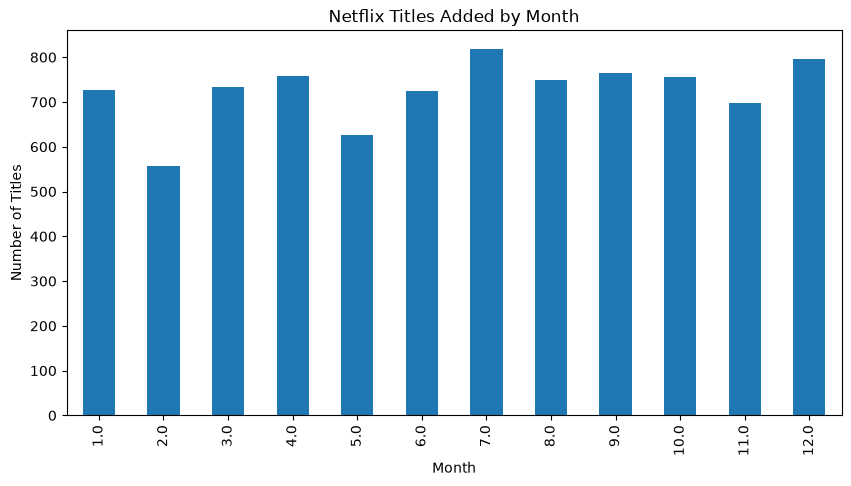

In [47]:
plt.figure(figsize=(10, 5))

month_count.plot(kind="bar")

plt.title("Netflix Titles Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.show()

In [48]:
# Longest movies
top_10_movies = (
    data[data["type"] == "Movie"]
    .sort_values("duration_minutes", ascending=False)
    .head(10)
)
top_10_movies[["title", "duration_minutes"]]

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


In [49]:
top_10_movies = (
    data[data["type"] == "TV Show"]
    .sort_values("rating", ascending=False)
    .head(10)
)

top_10_movies[["title", "duration_minutes","year_added"]]



,title,duration_minutes,year_added
7646,Oh No! It's an Alien Invasion,NaN,NaN
3695,Rabbids Invasion,NaN,2019.0
3066,Mia and Me,NaN,2020.0
3345,The Deep,NaN,2019.0
3295,Green Eggs and Ham,NaN,2019.0
3247,Trolls: The Beat Goes On!,NaN,2019.0
3246,The Dragon Prince,NaN,2019.0
3148,What's New Scooby-Doo?,NaN,2019.0
3146,Scooby-Doo!: Mystery Incorporated,NaN,2019.0
3085,Robot Trains,NaN,2019.0


In [50]:
top_10_movies = (
    data[data["type"] == "Movie"]
    .sort_values("duration_minutes", ascending=False)
    .head(10)
)

top_10_movies[["title", "duration_minutes"]]

,title,duration_minutes
4253,Black Mirror: Bandersnatch,312.0
717,Headspace: Unwind Your Mind,273.0
2491,The School of Mischief,253.0
2487,No Longer kids,237.0
2484,Lock Your Girls In,233.0
2488,Raya and Sakina,230.0
166,Once Upon a Time in America,229.0
7932,Sangam,228.0
1019,Lagaan,224.0
4573,Jodhaa Akbar,214.0


In [51]:
movie_country_count = (
    data[data["type"] == "Movie"]["country"]
    .str.split(", ")
    .explode()
    .value_counts()
)

movie_country_count.head(10)

country
United States     2751
India              962
United Kingdom     532
Unknown            440
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Name: count, dtype: int64

In [52]:
!pip install squarify


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


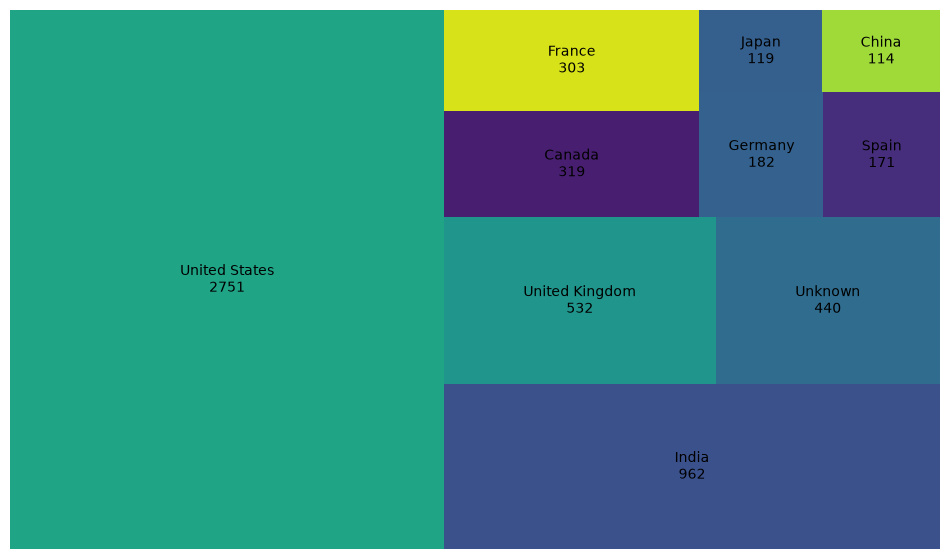

In [53]:
import squarify

top_10 = movie_country_count.head(10)

labels = [f"{country}\n{count}" for country, count in top_10.items()]

plt.figure(figsize=(12, 7))
squarify.plot(sizes=top_10.values, label=labels)

plt.axis("off")
plt.show()

In [61]:
tv_shows = data.loc[data["type"] == "TV Show", ["title", "duration"]].copy()
tv_shows["seasons"] = tv_shows["duration"].str.extract(r"(\d+)")[0].astype(int)
top10 = tv_shows.sort_values("seasons", ascending=False).head(10)

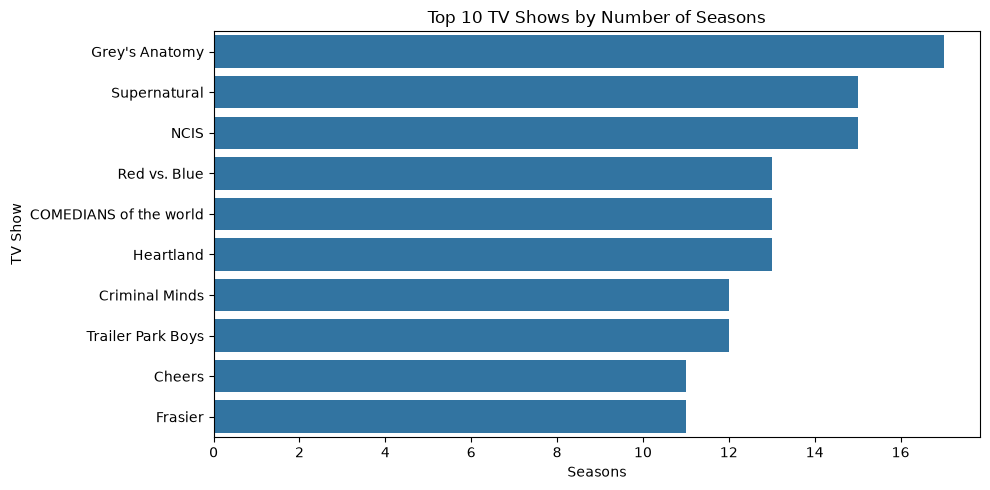

In [62]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x="seasons", y="title")
plt.title("Top 10 TV Shows by Number of Seasons")
plt.xlabel("Seasons")
plt.ylabel("TV Show")
plt.tight_layout()
plt.show()